In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import mizatools

In [5]:
# path1 = '/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all_dist.csv'
# path2 = '/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all_x_gaia_espels.csv'
# path3 = '/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/halpha_emitters_mc_simbad_and_all.csv'
path4 = '/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/all_detections_mc.csv'

In [6]:
# one = pd.read_csv(path1)
# two = pd.read_csv(path2)
# three = pd.read_csv(path3)
four = pd.read_csv(path4)    


/tmp/ipykernel_14794/1336397193.py:4: DtypeWarning: Columns (41) have mixed types. Specify dtype option on import or set low_memory=False.
  four = pd.read_csv(path4)


In [7]:
# (len(one), len(two), len(three), len(four))
len(four)

9851341

In [8]:
#check if all df have the same columns and what columns are missing in each one
# set_one = set(one.columns)
# set_two = set(two.columns)
# set_three = set(three.columns)
set_four = set(four.columns)

In [9]:
set_four

{'cluster_Names',
 'cluster_Type',
 'cluster_[M/H]',
 'cluster_amaj',
 'cluster_dec',
 'cluster_index',
 'cluster_r_[M/H]',
 'cluster_ra',
 'dec',
 'err_mag_psf_g',
 'err_mag_psf_i',
 'err_mag_psf_j0378',
 'err_mag_psf_j0395',
 'err_mag_psf_j0410',
 'err_mag_psf_j0430',
 'err_mag_psf_j0515',
 'err_mag_psf_j0660',
 'err_mag_psf_j0861',
 'err_mag_psf_r',
 'err_mag_psf_u',
 'err_mag_psf_z',
 'h_alpha_emitters_8sigma',
 'id',
 'mag_psf_g',
 'mag_psf_i',
 'mag_psf_j0378',
 'mag_psf_j0395',
 'mag_psf_j0410',
 'mag_psf_j0430',
 'mag_psf_j0515',
 'mag_psf_j0660',
 'mag_psf_j0861',
 'mag_psf_r',
 'mag_psf_u',
 'mag_psf_z',
 'outside_cluster',
 'ra',
 's2noise_r',
 'sep_arcmin',
 'sep_arcsec',
 'star_dec',
 'star_id',
 'star_index',
 'star_ra',
 'unique_values_kept'}

In [10]:
td = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/splus_figueiredo_objects_all.csv')

bes = pd.read_csv('/home/shared/splus_gaia/data/h-alpha-selection-marina/MC/Be_stars/be_stars_smc_lmc.csv')

bes['OGLE'] = bes['OGLE'].str.upper()

be = pd.merge(td, bes, right_on='OGLE', left_on='OGLE-II', how='inner')

In [12]:
four['Figueiredo_Be'] = four['id'].isin(be['id'])

In [22]:
four[(four['Figueiredo_Be'] == True)& (four['unique_values_kept'] == True)]

,id,ra,dec,mag_psf_g,mag_psf_i,mag_psf_j0378,mag_psf_j0395,mag_psf_j0410,mag_psf_j0430,mag_psf_j0515,...,cluster_dec,cluster_amaj,cluster_Names,cluster_Type,cluster_[M/H],cluster_r_[M/H],star_ra,star_dec,star_id,Figueiredo_Be
4887,i06MC0095035C8,16.004759,-72.553190,13.113133,13.334339,NaN,12.895820,12.957583,12.968610,13.075035,...,-72.548333,1.85,BIS663,A,NaN,NaN,16.004759,-72.553190,i06MC0095035C8,True
4888,i06MC0095035C8,16.004759,-72.553190,13.113133,13.334339,NaN,12.895820,12.957583,12.968610,13.075035,...,-72.615833,5.70,H-A52,A,NaN,NaN,16.004759,-72.553190,i06MC0095035C8,True
4889,i06MC0095035C8,16.004759,-72.553190,13.113133,13.334339,NaN,12.895820,12.957583,12.968610,13.075035,...,-72.395833,11.00,DEMS125,NaN,NaN,NaN,16.004759,-72.553190,i06MC0095035C8,True
4890,i06MC0095035C8,16.004759,-72.553190,13.113133,13.334339,NaN,12.895820,12.957583,12.968610,13.075035,...,-72.516111,14.00,DEMS134,NaN,NaN,NaN,16.004759,-72.553190,i06MC0095035C8,True
4891,i06MC0095035C8,16.004759,-72.553190,13.113133,13.334339,NaN,12.895820,12.957583,12.968610,13.075035,...,-72.503056,20.00,DEMS114,NaN,NaN,NaN,16.004759,-72.553190,i06MC0095035C8,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7882961,i06MC011505RTI,12.843447,-73.511521,18.546669,19.051900,18.462029,18.346527,18.343783,18.281008,18.542746,...,-73.497222,2.73,BIS385,A,NaN,NaN,12.843447,-73.511521,i06MC011505RTI,True
7882962,i06MC011505RTI,12.843447,-73.511521,18.546669,19.051900,18.462029,18.346527,18.343783,18.281008,18.542746,...,-73.445000,7.00,DEMS70s,NaN,NaN,NaN,12.843447,-73.511521,i06MC011505RTI,True
8441113,i06MC006509WN9,82.456876,-69.524410,18.329594,18.825873,18.599198,18.204860,18.193503,18.175501,18.383995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
8604822,i06MC00640FNMN,78.365176,-69.078620,18.843173,18.623127,19.081604,19.026667,18.898061,18.886984,18.780026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [28]:
len(four[(four['outside_cluster']== 0) & (four['cluster_Type']== 'C')])

245129

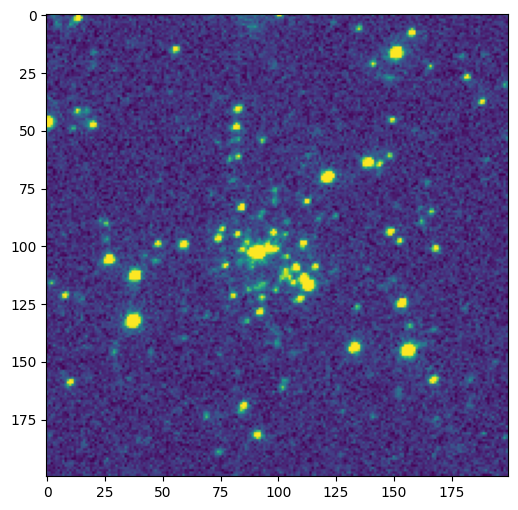

In [58]:
import splusdata 

client = splusdata.Core('marinaiza', 'Mari1407*')

cluster = client.stamp(ra = 73.9875, dec= -75.14027777777778, size = 200, band = 'r')

vmin = np.percentile(cluster[1].data, 1)
vmax = np.percentile(cluster[1].data, 99)

fig, ax_img = plt.subplots(figsize=(6,6))
ax_img.imshow(cluster[1].data,  vmin=vmin, vmax=vmax)

In [62]:
four.to_csv(path4, index=False)